# Librerias necesarias

In [32]:
import numpy as np
import pandas as pd
import re
import scipy.stats
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [33]:
import warnings
warnings.filterwarnings('ignore')

# Exercise 1 (1 point)


Read file IMDb_All_Genres_etf_clean1.csv
It contains information of more than 5000 films in IMDB
- 'Movie_Title' : Consist of 5000+ Movie Titles (5000+ Unique Values)
- 'Year' : Ranging from 1920s to 2022 (99 Unique Values)
- 'Director' : Names the Director (2000+ Unique Values)
- 'Actors' : Names the Actors (5000+ Unique & Multiple Values)
- 'Rating' : Titles rated for 10 by 25k+ Voters (74+ Unique Values)
- 'main_genre' : Main Genre of the Title (13+ Unique Values)
- 'side_genre' : Side / Multiple Genre of the Movie (144+ Unique & Multiple Values)
- 'Runtime(Mins)' : Total duration of the movie in Minutes (156+ Unique Values)
- 'Censor' : Censorship of the Movie (25+ Unique Values)
- 'Total_Gross' : Total Box-Office Collection of the Movie (3500+ Unique Values)


In [34]:
df = pd.read_csv("data\IMDb_All_Genres_etf_clean1.csv", delimiter=",")

# Exercise 2 (1 point)

- Change the Total_Gross to number (numer of $M) 
- Use the function re.sub(pattern, repl, string, count=0, flags=0), for regular expressions
- Total_Gross = float(re.sub("\$", "", Total_Gross_old)) # note, you should also eliminate the final M
- Remove rows with  'Gross Unkown' 


In [35]:
df = df[df["Total_Gross"] != "Gross Unkown"].reset_index()

In [36]:
df["Total_Gross"] = [float(re.sub("M","",re.sub("\$","",i))) for i in df["Total_Gross"].values]

# Exercise 3 (2 point)

Divide films by decade, do a barplot with the number of times of the most 5 popular genres ('main_genre') 

In [37]:
df["Decade"] = df["Year"] - df["Year"] % 10

In [38]:
df2 = df.groupby(["Decade","main_genre"]).count()["Movie_Title"].reset_index()
df2["Count"] = df2["Movie_Title"]

In [39]:
top5 = df2.sort_values(["Decade", "Count"],ascending=[True,False]).groupby("Decade").head(5)

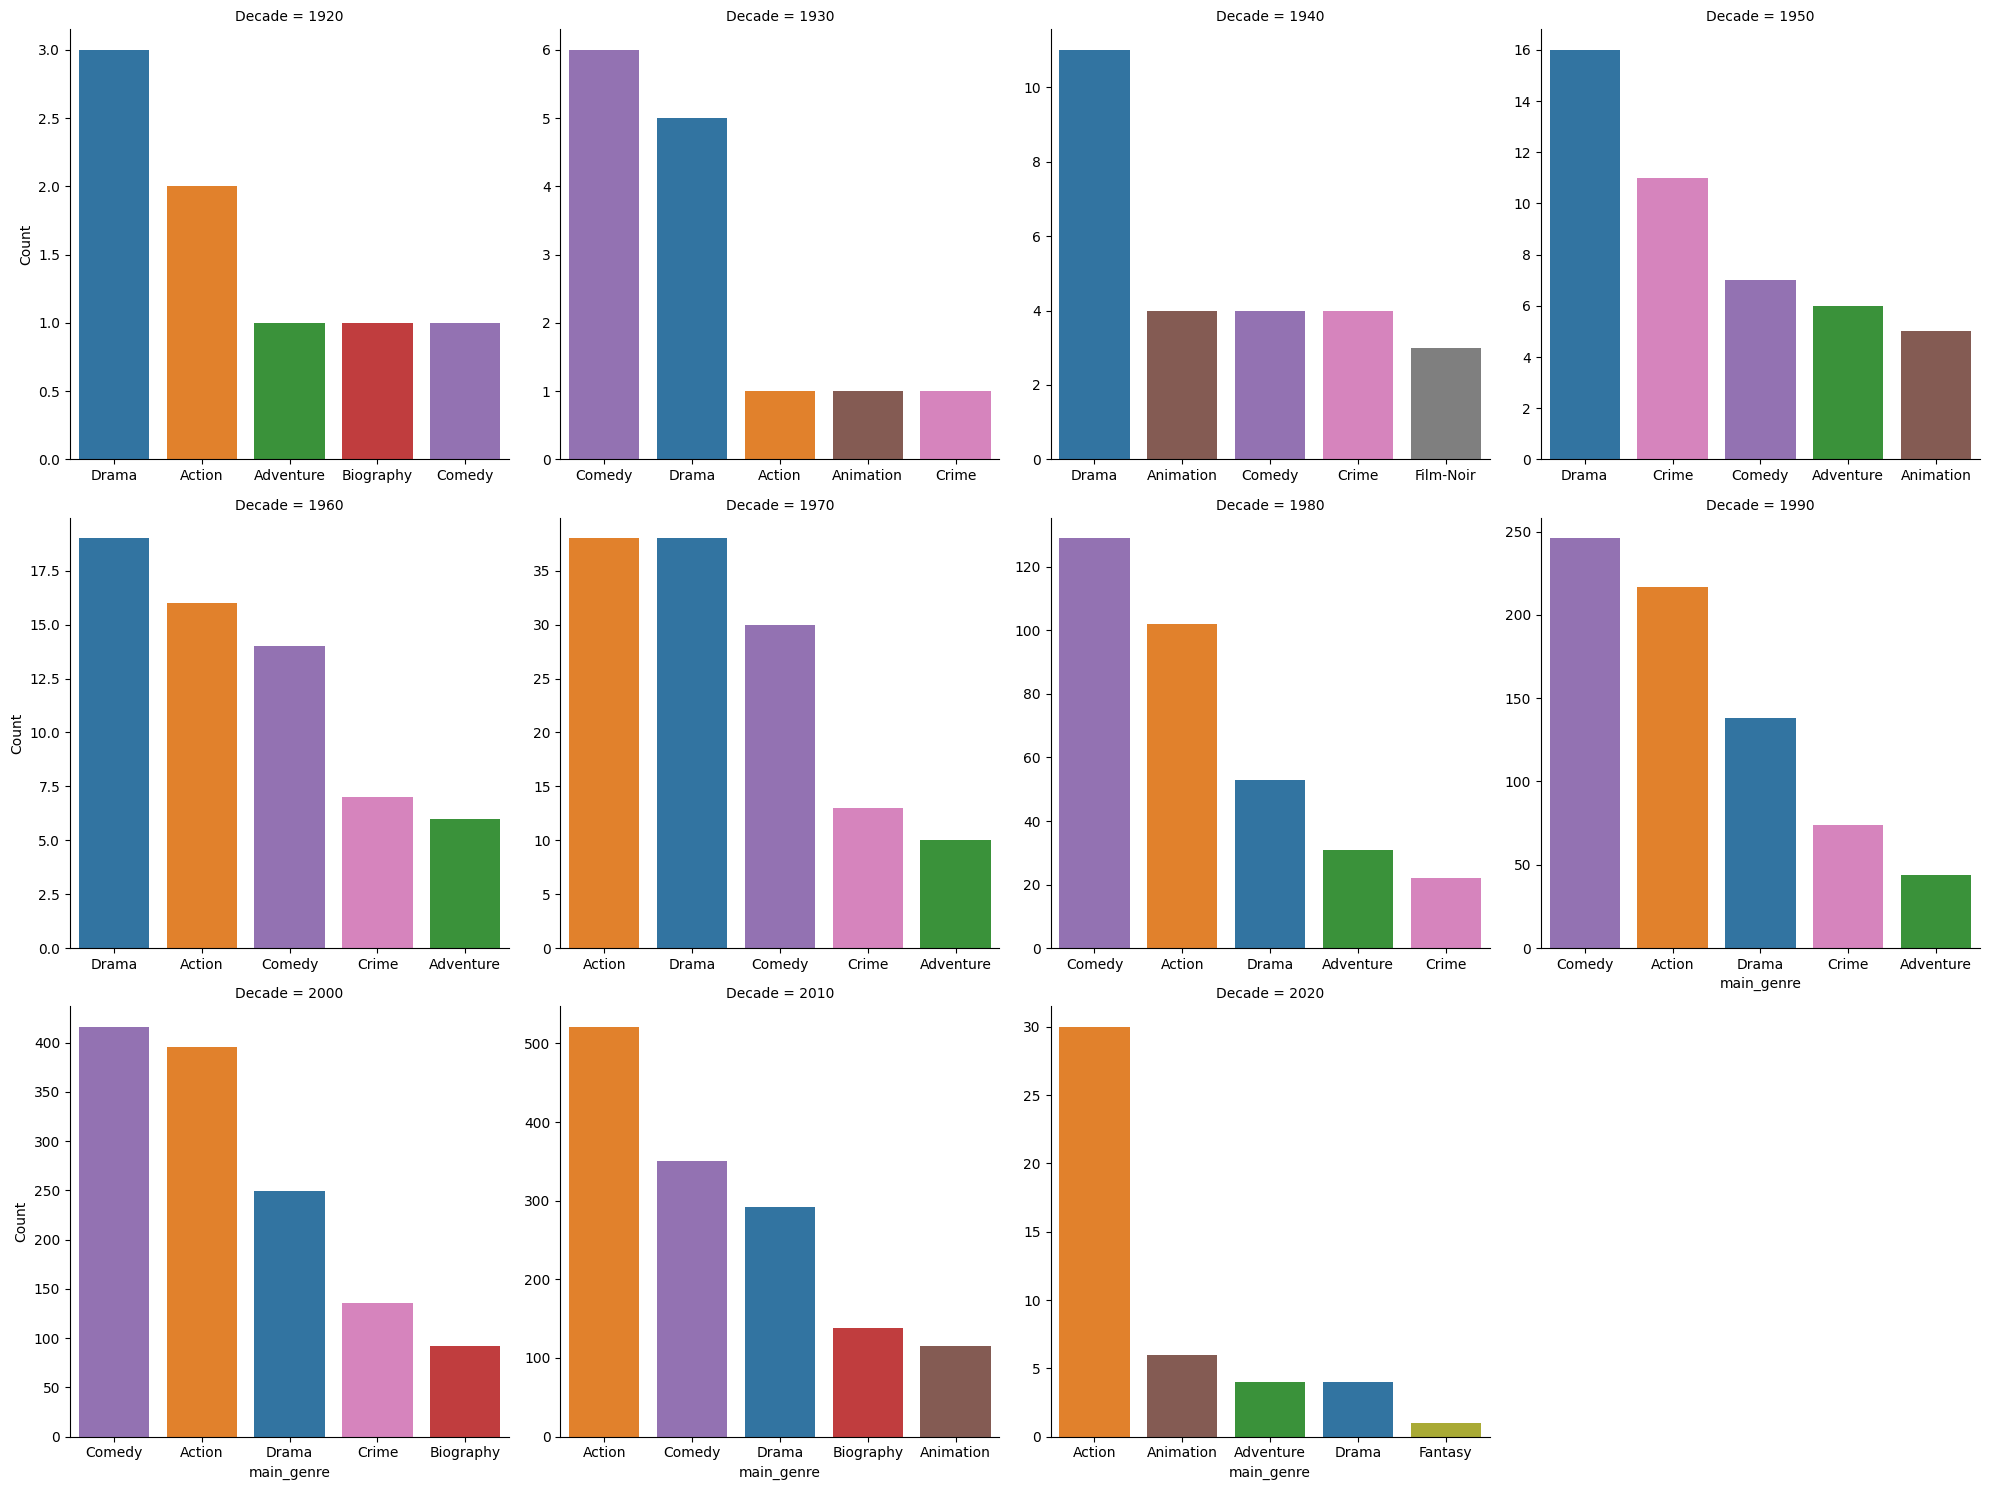

In [40]:
sns.catplot(kind = "bar", x = "main_genre",
            y = "Count", col="Decade", col_wrap=4, hue = "main_genre" , sharex=False, sharey=False,
            legend=False, data = top5)

# Exercise 4 (1 point)

- Draw the mean income by main_genre along decades
- For this plot, only retain genres that appear more than 200 times in total
- Remember that sns.relplot(kind = "line") uses the mean value


In [41]:
df3 = df.groupby("main_genre").count()["index"].sort_values(ascending=False).reset_index()
df3 = df3[df3["index"] > 200]

In [42]:
df3 = df[df["main_genre"].isin(df3["main_genre"].values)]

In [43]:
df3 = df3.groupby(["Decade","main_genre"])["Total_Gross"].mean().reset_index()

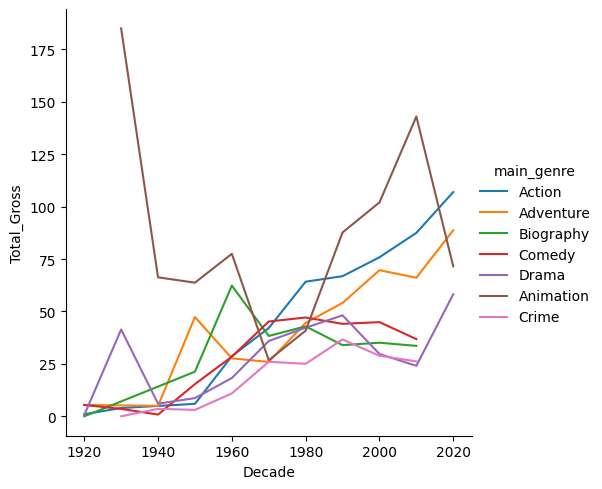

In [44]:
sns.relplot(kind = "line", x = "Decade", y = "Total_Gross", hue = "main_genre", data = df3)

# Exercise 5 (3 point)

- Determine if any main genre is "better" than the rest.? (Hint: compare one against the rest)<br>
<br>
Compare the 'Rating', 'Total_Gross' and 'Runtime(Mins)'. You can use either:

-   t-test [scipy.stats.ttest_ind]
-   wilcoxon-test [scipy.stats.ranksums]
-   anova [scipy.stats.f_oneway]
-   krustal-wallis [scipy.stats.kruskal]

To answer this question, reason your answer. For this part of the code reduce the data to from 1980 to 2019

In [45]:
df4 = df.loc[(df["Year"]>=1980) & (df["Year"]<=2019)]
df4.head()

,index,Movie_Title,Year,Director,Actors,Rating,Runtime(Mins),Censor,Total_Gross,main_genre,side_genre,Decade
0,1,The Dark Knight,2008,Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",9.0,152,UA,534.86,Action,"Crime, Drama",2000
1,2,The Lord of the Rings: The Return of the King,2003,Peter Jackson,"Elijah Wood, Viggo Mortensen, Ian McKellen, Or...",9.0,201,U,377.85,Action,"Adventure, Drama",2000
2,3,Inception,2010,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...",8.8,148,UA,292.58,Action,"Adventure, Sci-Fi",2010
3,4,The Lord of the Rings: The Two Towers,2002,Peter Jackson,"Elijah Wood, Ian McKellen, Viggo Mortensen, Or...",8.8,179,UA,342.55,Action,"Adventure, Drama",2000
4,5,The Lord of the Rings: The Fellowship of the Ring,2001,Peter Jackson,"Elijah Wood, Ian McKellen, Orlando Bloom, Sean...",8.8,178,U,315.54,Action,"Adventure, Drama",2000


ShapiroResult(statistic=np.float64(0.9734543538096174), pvalue=np.float64(1.2073146825825157e-27))

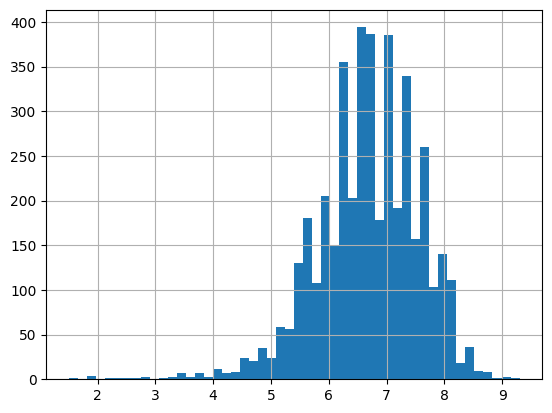

In [46]:
df4['Rating'].hist(bins=50)
scipy.stats.shapiro(df4['Rating'])

ShapiroResult(statistic=np.float64(0.6661367061821644), pvalue=np.float64(1.8541769382607302e-68))

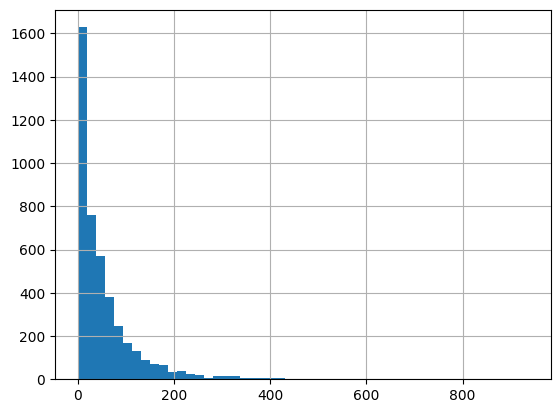

In [47]:
df4['Total_Gross'].hist(bins=50)
scipy.stats.shapiro(df4['Total_Gross'])

ShapiroResult(statistic=np.float64(0.9142545946356505), pvalue=np.float64(3.3904025744467975e-44))

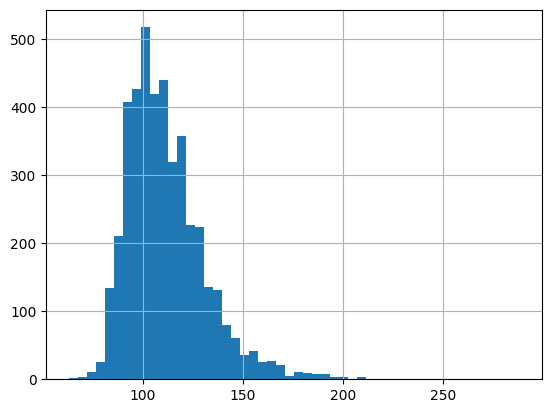

In [48]:
df4['Runtime(Mins)'].hist(bins=50)
scipy.stats.shapiro(df4['Runtime(Mins)'])

In [49]:
from scipy.stats import ranksums

for genre in df4["main_genre"].unique():
    group1 = df4[df4["main_genre"] == genre]["Rating"]
    group2 = df4[df4["main_genre"] != genre]["Rating"]
    stat, p_value = ranksums(group1, group2, alternative='greater')
    if p_value < 0.05:
        print(f"{genre} tiene más puntuación que el resto (p-valor: {p_value})")

Animation tiene más puntuación que el resto (p-valor: 5.704430889566267e-08)
Biography tiene más puntuación que el resto (p-valor: 1.0394962749975107e-31)
Drama tiene más puntuación que el resto (p-valor: 3.812394789080123e-33)
Crime tiene más puntuación que el resto (p-valor: 1.1410586945648209e-13)


In [50]:
for genre in df4["main_genre"].unique():
    group1 = df4[df4["main_genre"] == genre]["Total_Gross"]
    group2 = df4[df4["main_genre"] != genre]["Total_Gross"]
    stat, p_value = ranksums(group1, group2, alternative='greater')
    if p_value < 0.05:
        print(f"{genre} ha recaudado más que el resto (p-valor: {p_value})")

Action ha recaudado más que el resto (p-valor: 2.4698660684705755e-36)
Animation ha recaudado más que el resto (p-valor: 3.808476481619072e-26)
Adventure ha recaudado más que el resto (p-valor: 0.01725548194712018)


In [51]:
for genre in df4["main_genre"].unique():
    group1 = df4[df4["main_genre"] == genre]["Runtime(Mins)"]
    group2 = df4[df4["main_genre"] != genre]["Runtime(Mins)"]
    stat, p_value = ranksums(group1, group2, alternative='greater')
    if p_value < 0.05:
        print(f"{genre} dura más que el resto (p-valor: {p_value})")

Action dura más que el resto (p-valor: 3.3520536476148153e-20)
Biography dura más que el resto (p-valor: 8.0262133243955145e-28)
Drama dura más que el resto (p-valor: 1.3189827542976817e-22)
Crime dura más que el resto (p-valor: 3.6050083172736734e-07)
Mystery dura más que el resto (p-valor: 0.04545547218555973)


# Exercise 6 (2 point)

Construct a count matrix X for the different actors in the films <br>
Consider using this code: <br>




In [52]:
Actors = {i for i in re.split(', ', df.Actors[0])}
for i in df.Actors:
    for j in re.split(', ', i):
        Actors.add(j)
Actors = np.sort([i for i in Actors])
print(Actors)
Actors = np.sort([i for i in Actors])
print(len(Actors))

[' Star:Robert Redford' "'Weird Al' Yankovic" '50 Cent' ...
 'Émilie Leclerc' 'Ólafur Darri Ólafsson' 'Óscar Jaenada']
6873


Then:
- Delete variables with total frequency less than 10
- Apply PCA and plot the first 2 components
- Plot the PCA twice, one coloring by total_gross and other by main_genre.
- Do actors cluster revenue and by genre?

You can use from sklearn.decomposition import PCA

In [53]:
X = np.zeros((len(df),len(Actors)))

for i in range(len(df)):
    aux = re.split(', ', df["Actors"][i])
    X[i, np.isin(Actors, aux)] = 1
    

In [54]:
from operator import index


total_freq = X.sum(axis=0)

#index of cases in which total_freq is greater than 10
keep = np.where(total_freq > 10)[0]
keep

X = X[:, keep]
Actors = Actors[keep]
print(X.shape)

(4701, 345)


In [55]:
from sklearn.decomposition import PCA

In [56]:
from sklearn.preprocessing import StandardScaler
mat2 = X
scaler = StandardScaler()
scaler.fit(mat2)
StandardScaler()
X = scaler.transform(mat2)


In [57]:
pca = PCA().fit(X)
X_pca = pca.transform(X)
X_dev = pca.explained_variance_ #regular PCA
X_eigenvectors = pca.components_ #regular PCA

In [58]:
print(type(X_pca))
print(X_pca.shape)
print(X_dev[:10])
print(X_eigenvectors[:10])

print(X_dev[:5]/np.sum(X_dev))
print(np.sum(X_dev))


<class 'numpy.ndarray'>
(4701, 345)
[1.91608439 1.76793465 1.74607371 1.72949248 1.69930423 1.67211642
 1.66011675 1.65219946 1.62222237 1.60332938]
[[-0.0052104   0.01233078 -0.00232119 ... -0.00632053 -0.02790684
  -0.02629282]
 [ 0.00953427  0.02501464 -0.04969616 ...  0.03273058 -0.00486929
   0.15742573]
 [-0.00878277  0.01555361  0.0283413  ... -0.02159166  0.04762063
   0.18019473]
 ...
 [-0.00753207 -0.00115718  0.02265723 ... -0.08149459  0.0780936
   0.00631764]
 [-0.00879215  0.01060436 -0.11660144 ... -0.05666215 -0.01284707
  -0.00155692]
 [ 0.00387209  0.06618283  0.18878509 ... -0.0507978   0.0571081
  -0.01141214]]
[0.00555269 0.00512336 0.00506001 0.00501196 0.00492447]
345.07340425531936


In [61]:
#data.frame with components and more info
dfr = pd.DataFrame(X_pca)
dfr.columns = ['PC' + str(i+1) for i in range(X_pca.shape[1])]
dfr["Total_Gross"] = df.Total_Gross
dfr["main_genre"] = df.main_genre
dfr["Decade"] = df.Decade
dfr["Rating"] = df.Rating
dfr["Year"] = df.Year
dfr.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC341,PC342,PC343,PC344,PC345,Total_Gross,main_genre,Decade,Rating,Year
0,2.476803,-0.136791,1.737561,-1.250337,3.449352,-0.026249,-3.435489,-0.885947,-0.868276,3.447848,...,0.193669,0.210281,-0.345246,-0.340394,-0.624976,534.86,Action,2000,9.0,2008
1,26.937864,5.259841,-2.209686,1.639660,3.633915,2.547341,0.619957,0.835831,-0.107505,-0.452065,...,-0.347960,-1.062996,-0.612589,1.343649,0.614954,377.85,Action,2000,9.0,2003
2,-0.216120,-0.776029,-0.020793,-0.055198,0.772857,-0.582469,1.009424,-1.249386,-0.885364,-1.418684,...,-1.796680,-1.096537,-0.359758,-0.190992,0.349773,292.58,Action,2010,8.8,2010
3,26.937864,5.259841,-2.209686,1.639660,3.633915,2.547341,0.619957,0.835831,-0.107505,-0.452065,...,-0.347960,-1.062996,-0.612589,1.343649,0.614954,342.55,Action,2000,8.8,2002
4,25.519876,5.524484,-2.291676,2.275234,2.565211,2.836741,0.183767,-0.328974,-1.064271,0.410515,...,0.382221,-1.271035,0.110753,0.792916,0.397938,315.54,Action,2000,8.8,2001


In [62]:
print(df.iloc[:5,:5])

   index                                        Movie_Title  Year  \
0      1                                    The Dark Knight  2008   
1      2      The Lord of the Rings: The Return of the King  2003   
2      3                                          Inception  2010   
3      4              The Lord of the Rings: The Two Towers  2002   
4      5  The Lord of the Rings: The Fellowship of the Ring  2001   

            Director                                             Actors  
0  Christopher Nolan  Christian Bale, Heath Ledger, Aaron Eckhart, M...  
1      Peter Jackson  Elijah Wood, Viggo Mortensen, Ian McKellen, Or...  
2  Christopher Nolan  Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio...  
3      Peter Jackson  Elijah Wood, Ian McKellen, Viggo Mortensen, Or...  
4      Peter Jackson  Elijah Wood, Ian McKellen, Orlando Bloom, Sean...  


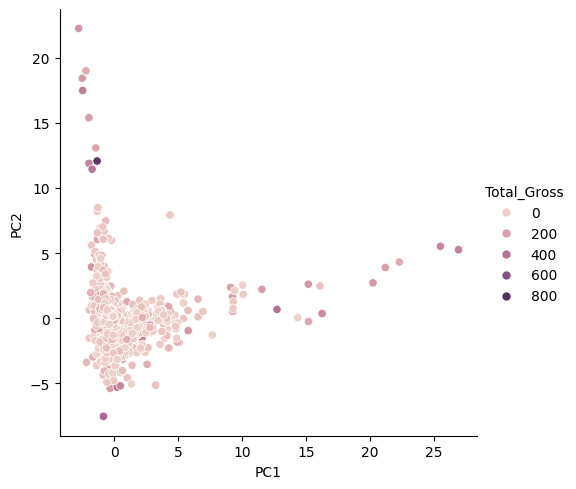

In [64]:
g = sns.relplot(dfr, x = "PC1", y = "PC2", hue="Total_Gross")

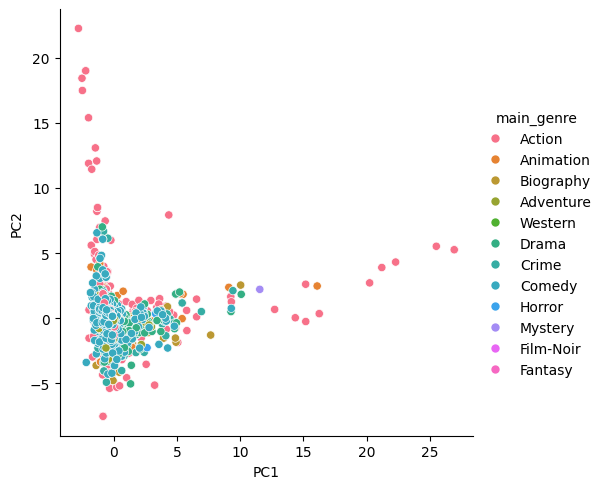

In [65]:
g = sns.relplot(dfr, x = "PC1", y = "PC2", hue="main_genre")

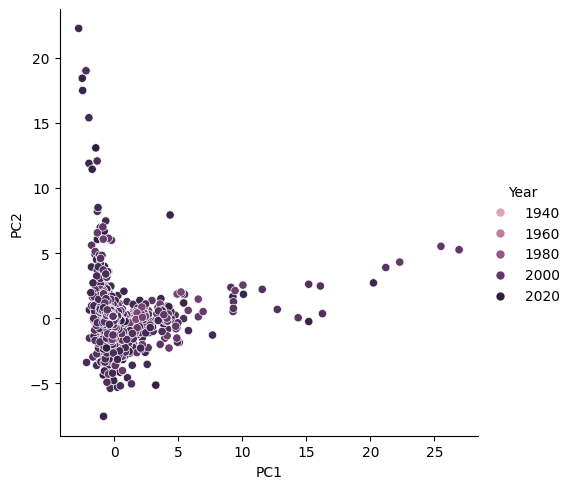

In [66]:
g = sns.relplot(dfr, x = "PC1", y = "PC2", hue="Year")

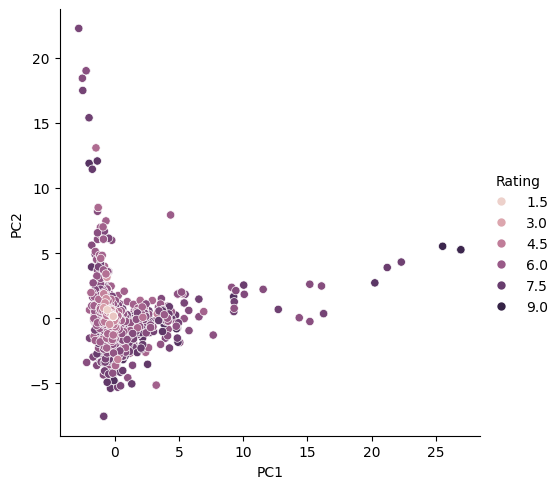

In [67]:
g = sns.relplot(dfr, x = "PC1", y = "PC2", hue="Rating")

<Axes: xlabel='PC1', ylabel='PC2'>

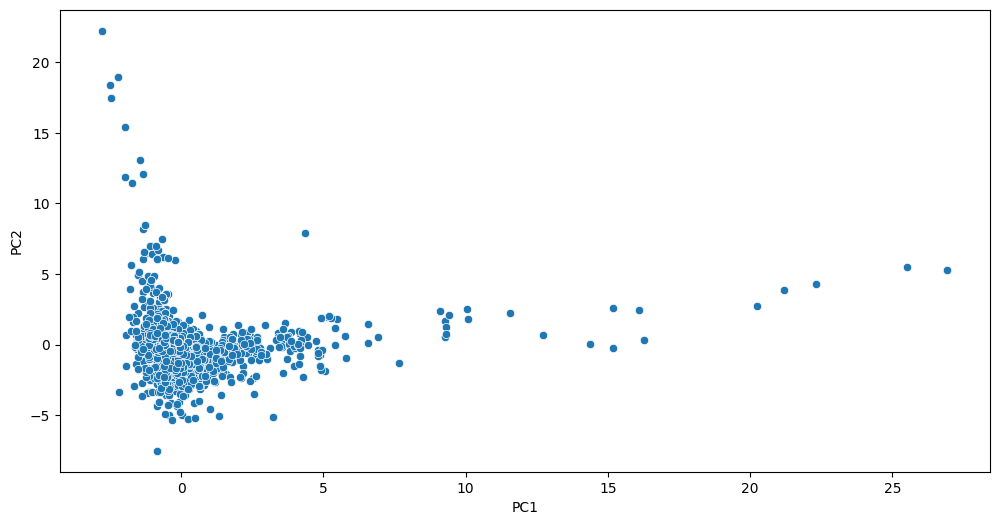

In [68]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

pcaDf = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2'])

plt.figure(figsize=(12, 6))
sns.scatterplot(data=pcaDf, x="PC1", y="PC2")